In [ ]:
!pip install -qq openai tqdm python-dotenv groq

In [18]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os

import os
from dotenv import load_dotenv
from openai import OpenAI
import json
from tqdm import tqdm 


# Load .env file
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [8]:
df = pd.read_csv('data/product_table.csv')
df.head()

,image_id,image_url,l1_category,product_name,price,category
0,MP000000029740902,https://img.tatacliq.com/images/i29/437Wx649H/...,Footwear,LUNA BLU by Westside Gold Multi-Strap Slides,999.0,Men's Casual Shoes
1,MP000000022615605,https://img.tatacliq.com/images/i18//437Wx649H...,Footwear,Saint G Women's Matilde Gold T-Strap Sandals,8900.0,Men's Casual Shoes
2,MP000000018260200,https://img.tatacliq.com/images/i12/437Wx649H/...,Footwear,Hush Puppies by Bata Women's Brown Thong Wedges,2999.0,Men's Casual Shoes
3,MP000000028195470,https://img.tatacliq.com/images/i26//437Wx649H...,Footwear,Skechers Women's Summits Mauve Slip-On Shoes,3839.0,Men's Casual Shoes
4,MP000000024268627,https://img.tatacliq.com/images/i20//437Wx649H...,Footwear,Metro Women's Brown Wedge Pumps,1748.5,Men's Casual Shoes


In [9]:
df.columns

Index(['image_id', 'image_url', 'l1_category', 'product_name', 'price',
       'category'],
      dtype='object')

In [ ]:
## 1. Extract the colour using AI (brand can be tried also as practice)

## 2. Similar products using embeddings generated from text + image (try both separately and then together)

In [6]:
## Checking the fill rate;

df.isnull().sum()

image_id        0
image_url       0
l1_category     0
product_name    0
price           0
category        0
dtype: int64

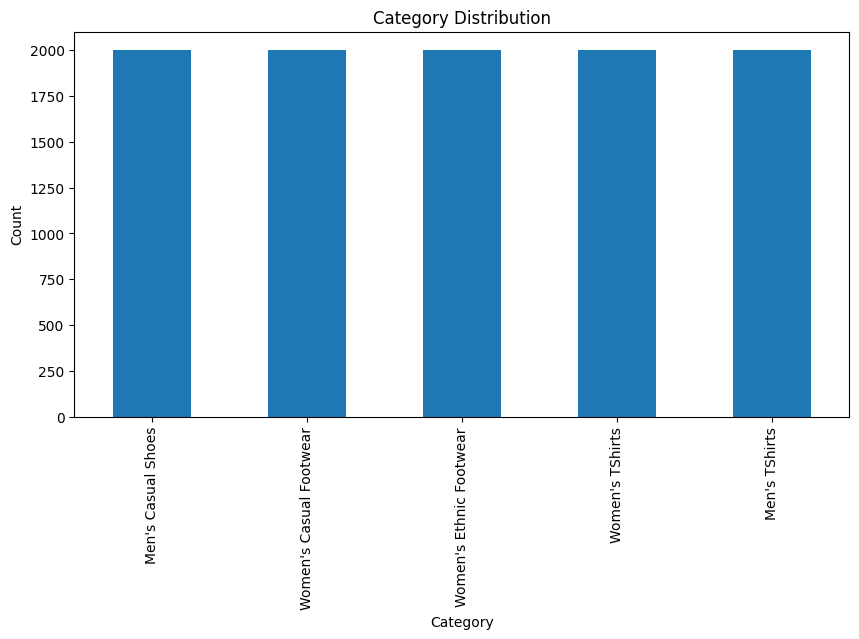

In [7]:
## Category distribution;

plt.figure(figsize=(10,5))
df['category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [9]:
## Check for blank values/space in the description column;
df['product_name'].str.isspace().sum()

0

# Task 1. Entity extraction using Open AI;



In [ ]:
client = OpenAI(api_key=OPENAI_API_KEY)

def extract_entities(product_name):
    
    prompt = f"""
Extract the parent brand and color from the following product descriptions. Do not include the brand with their sub-brands. 
For example, if the product is "Nike Air Max 90 Red", the brand should be "Nike" and not "Nike Air Max".

Product Description: "{product_name}"

Return output ONLY in JSON format like:
{{
 "brand": "",
 "color": ""
}}

If any field is missing return null.

For example, for the product title "LUNA BLU by Westside Gold Multi-Strap Slides", the output should be:

{{
 "brand": "Westside",
 "color": "Gold"
}}



"""

    response = client.chat.completions.create(
        model="gpt-4.1-mini",  # cheap and good for extraction
        messages=[
            {"role": "system", "content": "You are an E-Commerce product entity extractor."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    text = response.choices[0].message.content

    try:
        data = json.loads(text)
    except:
        data = {"brand": None, "color": None}

    return data

In [ ]:
brands = []
colors = []
n_rows = 50
for title in tqdm(df[["product_name"]].head(n_rows).values):

    res = extract_entities(title)

    brands.append(res["brand"])
    colors.append(res["color"])

# df["brand"] = brands
# df["color"] = colors

100%|██████████| 50/50 [00:46<00:00,  1.06it/s]


ValueError: Length of values (50) does not match length of index (10000)

In [33]:
temp = df[["product_name"]].head(n_rows)
temp.shape

(50, 1)

In [34]:
temp1 = pd.concat([temp, pd.DataFrame({'brand': brands, 'color': colors})], axis=1)

In [35]:
temp1.head()

,product_name,brand,color
0,LUNA BLU by Westside Gold Multi-Strap Slides,Westside,Gold
1,Saint G Women's Matilde Gold T-Strap Sandals,Saint G,Gold
2,Hush Puppies by Bata Women's Brown Thong Wedges,Bata,Brown
3,Skechers Women's Summits Mauve Slip-On Shoes,Skechers,Mauve
4,Metro Women's Brown Wedge Pumps,Metro,Brown


In [36]:
temp1

,product_name,brand,color
0,LUNA BLU by Westside Gold Multi-Strap Slides,Westside,Gold
1,Saint G Women's Matilde Gold T-Strap Sandals,Saint G,Gold
2,Hush Puppies by Bata Women's Brown Thong Wedges,Bata,Brown
3,Skechers Women's Summits Mauve Slip-On Shoes,Skechers,Mauve
4,Metro Women's Brown Wedge Pumps,Metro,Brown
5,Mochi Women's Black Loafers,Mochi,Black
6,Carlton London Women's Off-white Flip-Flops,Carlton London,Off-white
7,Mochi Women's White Casual Sandals,Mochi,White
8,Campus Women's Off White Slip-On Shoes,Campus,Off White
9,LUNA BLU by Westside Black Floral Detailed Poi...,Westside,Black


In [23]:
df.head(10)

,image_id,image_url,l1_category,product_name,price,category
0,MP000000029740902,https://img.tatacliq.com/images/i29/437Wx649H/...,Footwear,LUNA BLU by Westside Gold Multi-Strap Slides,999.0,Men's Casual Shoes
1,MP000000022615605,https://img.tatacliq.com/images/i18//437Wx649H...,Footwear,Saint G Women's Matilde Gold T-Strap Sandals,8900.0,Men's Casual Shoes
2,MP000000018260200,https://img.tatacliq.com/images/i12/437Wx649H/...,Footwear,Hush Puppies by Bata Women's Brown Thong Wedges,2999.0,Men's Casual Shoes
3,MP000000028195470,https://img.tatacliq.com/images/i26//437Wx649H...,Footwear,Skechers Women's Summits Mauve Slip-On Shoes,3839.0,Men's Casual Shoes
4,MP000000024268627,https://img.tatacliq.com/images/i20//437Wx649H...,Footwear,Metro Women's Brown Wedge Pumps,1748.5,Men's Casual Shoes
5,MP000000028326575,https://img.tatacliq.com/images/i27//437Wx649H...,Footwear,Mochi Women's Black Loafers,1943.5,Men's Casual Shoes
6,MP000000027778562,https://img.tatacliq.com/images/i26//437Wx649H...,Footwear,Carlton London Women's Off-white Flip-Flops,675.0,Men's Casual Shoes
7,MP000000016576141,https://img.tatacliq.com/images/i19//437Wx649H...,Footwear,Mochi Women's White Casual Sandals,819.5,Men's Casual Shoes
8,MP000000026707059,https://img.tatacliq.com/images/i24//437Wx649H...,Footwear,Campus Women's Off White Slip-On Shoes,999.0,Men's Casual Shoes
9,MP000000029778000,https://img.tatacliq.com/images/i29/437Wx649H/...,Footwear,LUNA BLU by Westside Black Floral Detailed Poi...,1499.0,Men's Casual Shoes


Observations:

Cost of extraction using gpt-4.1-mini is around 0.0008 USD per 1000 tokens. Assuming an average of 10 tokens per product title, the cost would be approximately 0.000008 USD per product. For 1 million products, the total cost would be around 8 USD.

In [59]:
## In order to save cost, let's try open source llms and compare the results;

# Load .env file
load_dotenv()

HF_API_KEY = os.getenv("HF_API_KEY")

In [ ]:
import requests
import json
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

def extract_entities_llama(product_name):

    prompt = f"""
    Extract the parent brand and color from the following product descriptions. 
    Do not include the brand with their sub-brands.

    For example, if the product is "Nike Air Max 90 Red", the brand should be "Nike" and not "Nike Air Max".

    Product Description: "{product_name}"

    Return output ONLY in JSON format like:
    {{
    "brand": "",
    "color": ""
    }}


    Rules:
    - Return ONLY valid JSON.
    - Do NOT explain anything.
    - Do NOT write code.
    - Do NOT include text outside JSON.

    If a field is missing return null.

    For example, for the product title "LUNA BLU by Westside Gold Multi-Strap Slides", the output should be:

    {{
    "brand": "Westside",
    "color": "Gold"
    }}
    """

    payload = {
        "inputs": prompt,
        "parameters": {
            "temperature": 0,
            "max_new_tokens": 100
        }
    }

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0,
        max_tokens=100
    )

    result = response.choices[0].message.content

    try:
        parsed_result = json.loads(result)
    except Exception as e:
        print(f"Error parsing JSON: {e}")
        parsed_result = {"brand": None, "color": None}

    return parsed_result
    

In [19]:
brands = []
colors = []
n_rows = 50
for title in tqdm(df[["product_name"]].head(n_rows).values):

    res = extract_entities_llama(title[0])

    brands.append(res["brand"])
    colors.append(res["color"])

100%|██████████| 50/50 [01:01<00:00,  1.24s/it]


In [20]:
temp = df[["product_name"]].head(n_rows)
temp1 = pd.concat([temp, pd.DataFrame({'brand': brands, 'color': colors})], axis=1)
temp1.head()

,product_name,brand,color
0,LUNA BLU by Westside Gold Multi-Strap Slides,Westside,Gold
1,Saint G Women's Matilde Gold T-Strap Sandals,Saint G,Gold
2,Hush Puppies by Bata Women's Brown Thong Wedges,Hush Puppies,Brown
3,Skechers Women's Summits Mauve Slip-On Shoes,Skechers,Mauve
4,Metro Women's Brown Wedge Pumps,Metro,Brown


In [21]:
temp1.tail()

,product_name,brand,color
45,Bata Women's Carlene Brown Casual Sandals,Bata,Brown
46,Kickers Women's KICK BIGEYE-IN Black Ankle Str...,Kickers,Black
47,Scholl Women's Light Green Thongs,Scholl,Light Green
48,ALDO Women's Black Slides,ALDO,Black
49,Hush Puppies Women's CELINE TEXTURE MULE Gold ...,Hush Puppies,Gold
